# Pairwise Comparisons with `stat_pwc`

This page uses `stat_pwc` to add pairwise comparison p-values to plotnine plots,
following the API style of
[ggpubr's `geom_pwc`](https://rpkgs.datanovia.com/ggpubr/reference/geom_pwc.html).

`stat_pwc` runs pairwise t-tests or Wilcoxon tests between groups and draws the
results as bracket annotations or text labels. The examples cover:

- all pairwise combinations
- comparisons against a reference group
- explicit comparison pairs
- paired tests with a required subject identifier via `wid`
- p-value adjustment methods (Bonferroni, Holm, BH, etc.)
- text-only labels with `remove_bracket=True`
- p-value and significance-star labels

## Setup

In [1]:
import numpy as np
import pandas as pd
from plotnine import (
    aes,
    geom_boxplot,
    geom_jitter,
    geom_line,
    geom_point,
    ggplot,
    labs,
    scale_y_continuous,
    theme_minimal,
    facet_wrap,
)
from plotnine_extra import stat_pwc

## Data Preparation

We use a dataset inspired by R's `ToothGrowth` dataset, which records
tooth length (`len`) across different supplement types (`supp`) and
dose levels (`dose`).

In [2]:
np.random.seed(42)

# Create a ToothGrowth-like dataset
df = pd.DataFrame({
    "dose": np.tile(np.repeat(["D0.5", "D1", "D2"], 10), 2),
    "supp": np.repeat(["OJ", "VC"], 30),
    "len": np.concatenate([
        # OJ groups
        np.random.normal(13, 4, 10),  # OJ, dose 0.5
        np.random.normal(23, 3, 10),  # OJ, dose 1
        np.random.normal(26, 2, 10),  # OJ, dose 2
        # VC groups
        np.random.normal(8, 3, 10),   # VC, dose 0.5
        np.random.normal(17, 4, 10),  # VC, dose 1
        np.random.normal(26, 3, 10),  # VC, dose 2
    ]),
})

df.head()

,dose,supp,len
0,D0.5,OJ,14.986857
1,D0.5,OJ,12.446943
2,D0.5,OJ,15.590754
3,D0.5,OJ,19.092119
4,D0.5,OJ,12.063387


## Basic Usage: All Pairwise Comparisons

By default, `stat_pwc` performs **all pairwise comparisons** between
x-axis groups using the Wilcoxon rank-sum test (Mann-Whitney U). The
default geom is `geom_bracket`, which draws brackets with p-value labels.

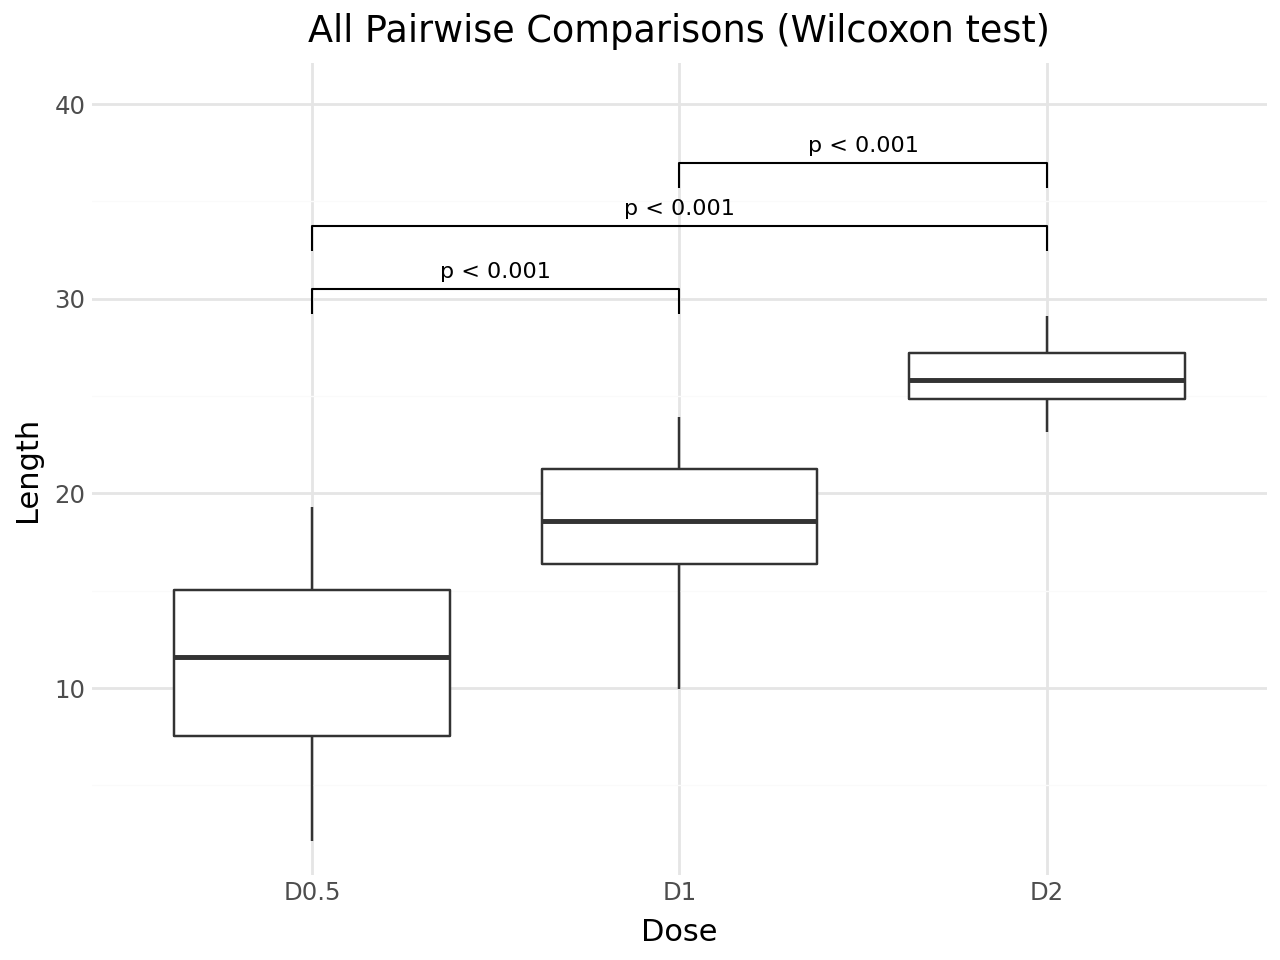

In [3]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot()
    + stat_pwc()
    + scale_y_continuous(expand=(0.05, 0, 0.15, 0))
    + labs(
        title="All Pairwise Comparisons (Wilcoxon test)",
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## Using t-test Instead of Wilcoxon

Set `method="t.test"` to use the independent samples t-test.

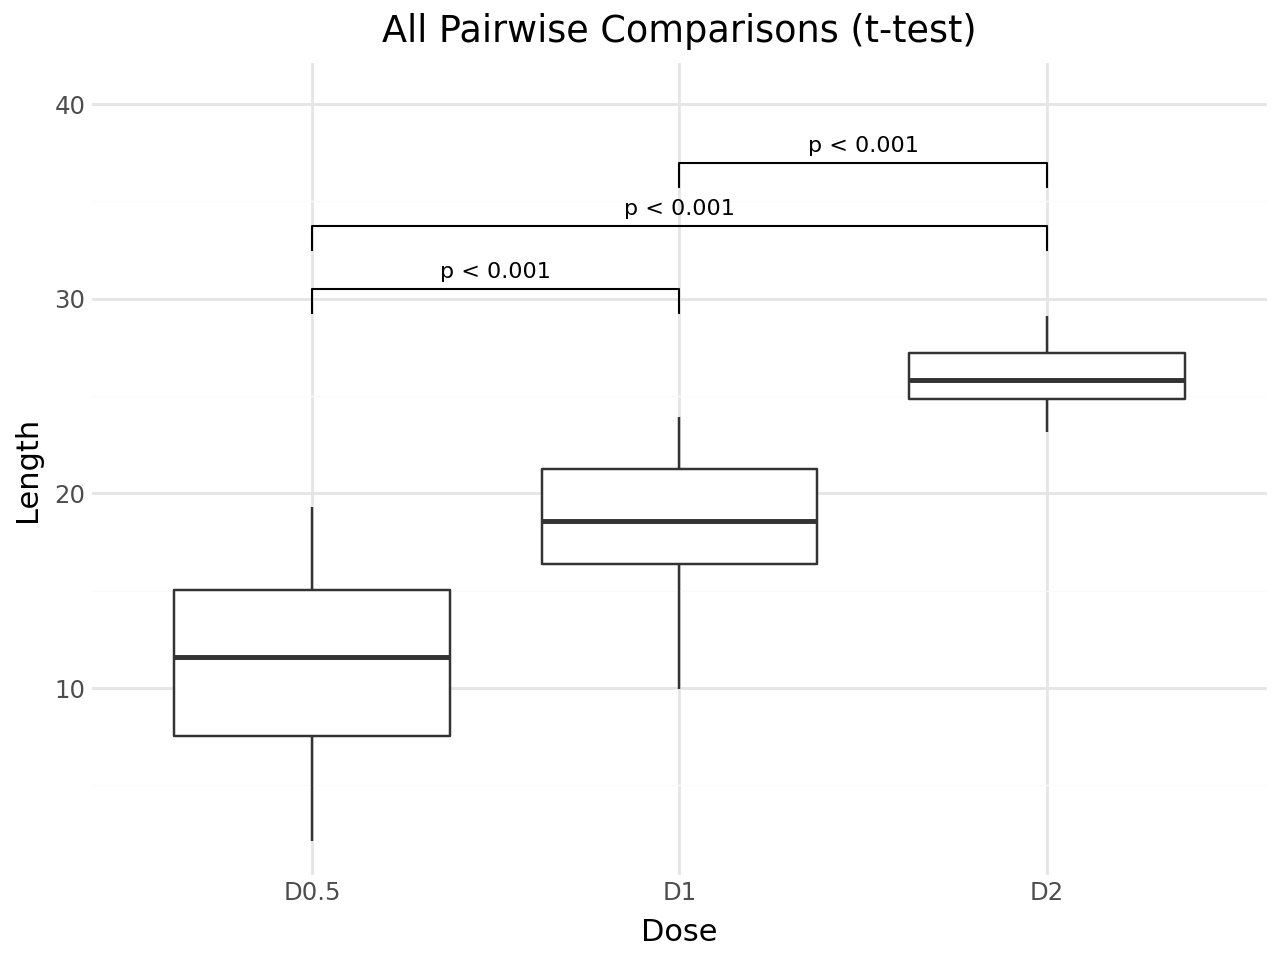

In [4]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot()
    + stat_pwc(method="t.test")
    + scale_y_continuous(expand=(0.05, 0, 0.15, 0))
    + labs(
        title="All Pairwise Comparisons (t-test)",
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## Significance Stars

Use `label="p.signif"` to display significance stars instead of
p-values. The convention is:

| Symbol | Meaning |
|--------|----------|
| `ns`   | p > 0.05 |
| `*`    | p ≤ 0.05 |
| `**`   | p ≤ 0.01 |
| `***`  | p ≤ 0.001 |
| `****` | p ≤ 0.0001 |

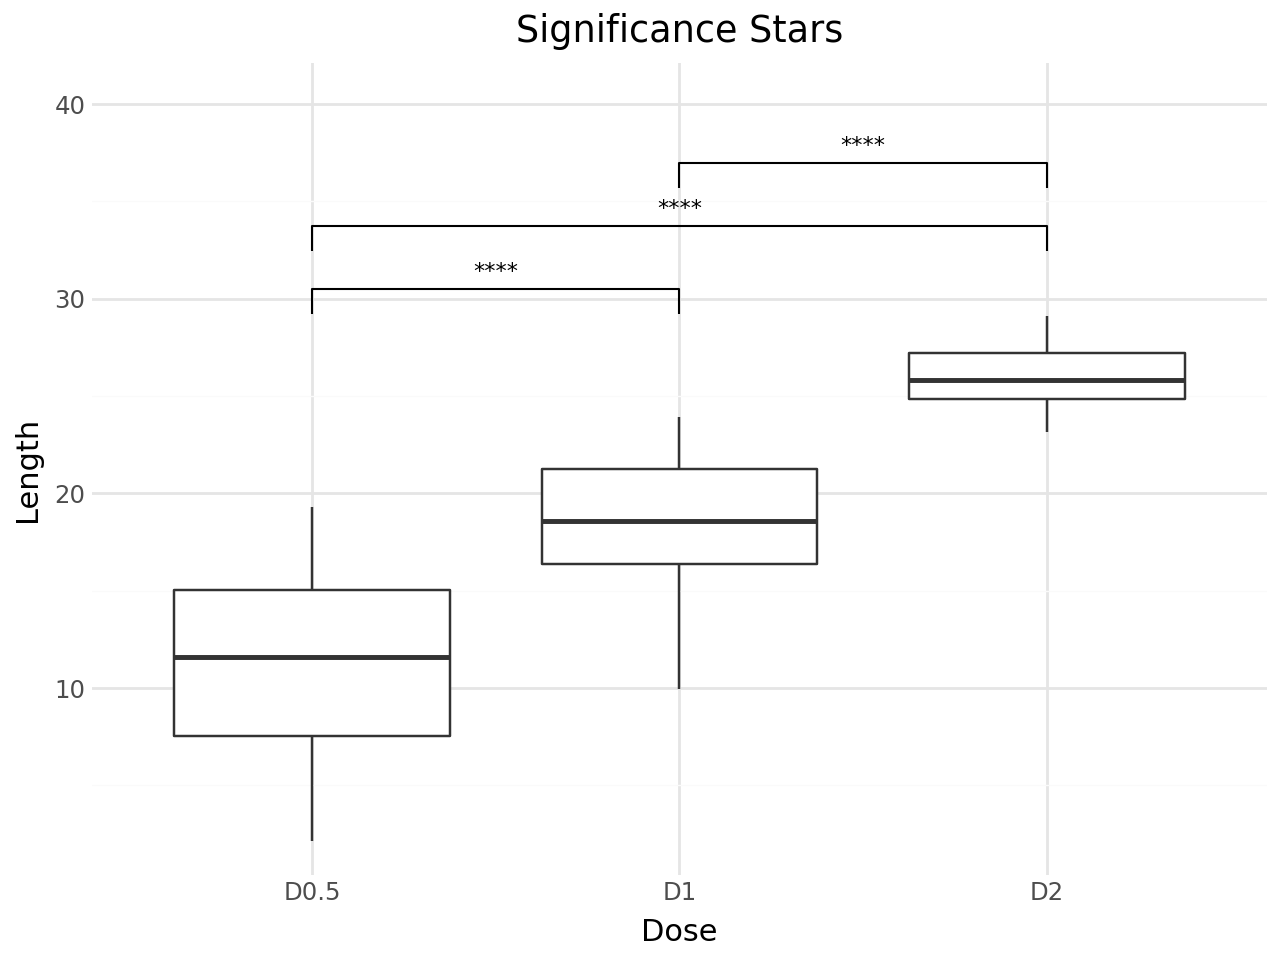

In [5]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot()
    + stat_pwc(label="p.signif")
    + scale_y_continuous(expand=(0.05, 0, 0.15, 0))
    + labs(
        title="Significance Stars",
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## Comparisons against a reference group

Use `ref_group` to compare each group against a reference, for example a control
or baseline group.

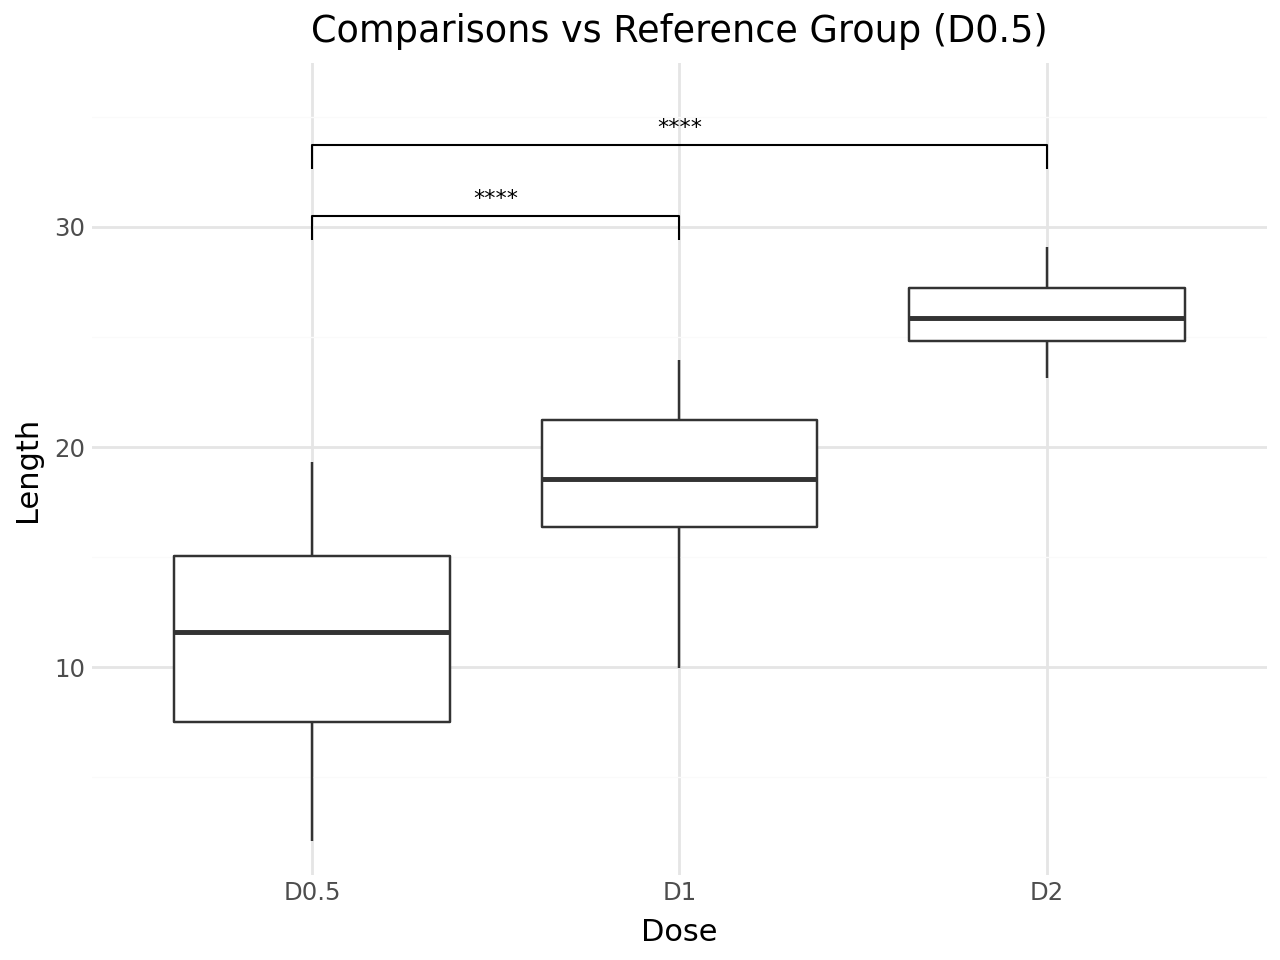

In [6]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot()
    + stat_pwc(
        ref_group="D0.5",
        label="p.signif",
        method="t.test",
    )
    + scale_y_continuous(expand=(0.05, 0, 0.12, 0))
    + labs(
        title='Comparisons vs Reference Group (D0.5)',
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## Explicit Comparison Pairs

Specify exactly which pairs to compare with the `comparisons` parameter.

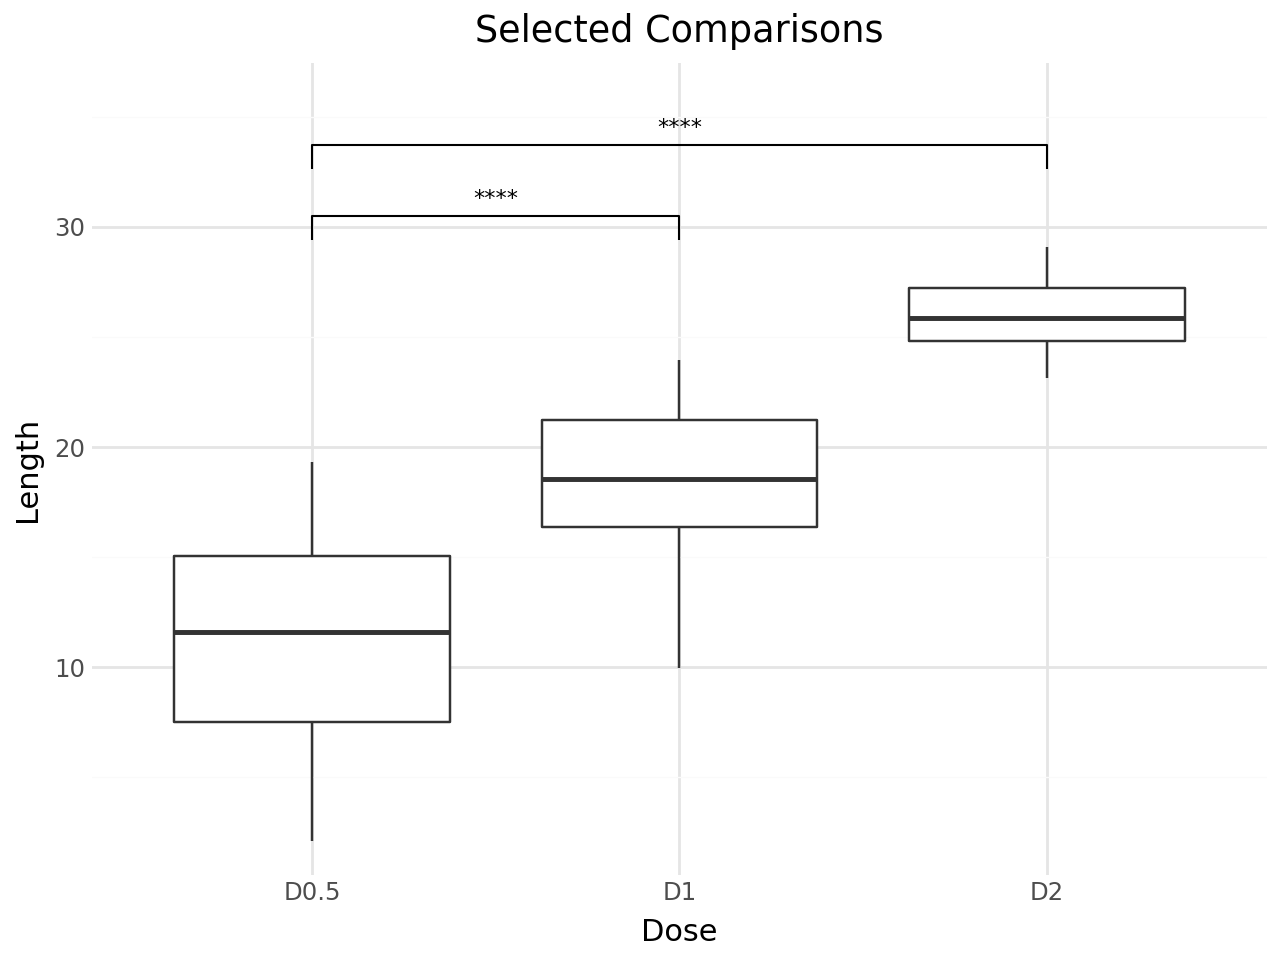

In [7]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot()
    + stat_pwc(
        comparisons=[("D0.5", "D1"), ("D0.5", "D2")],
        label="p.signif",
    )
    + scale_y_continuous(expand=(0.05, 0, 0.12, 0))
    + labs(
        title="Selected Comparisons",
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## P-value Adjustment

`stat_pwc` adjusts p-values for multiple comparisons by default using
the Holm method. You can change the adjustment method with
`p_adjust_method`.

Use `label="p.adj.format"` to display adjusted p-values, or
`label="p.adj.signif"` for adjusted significance stars.

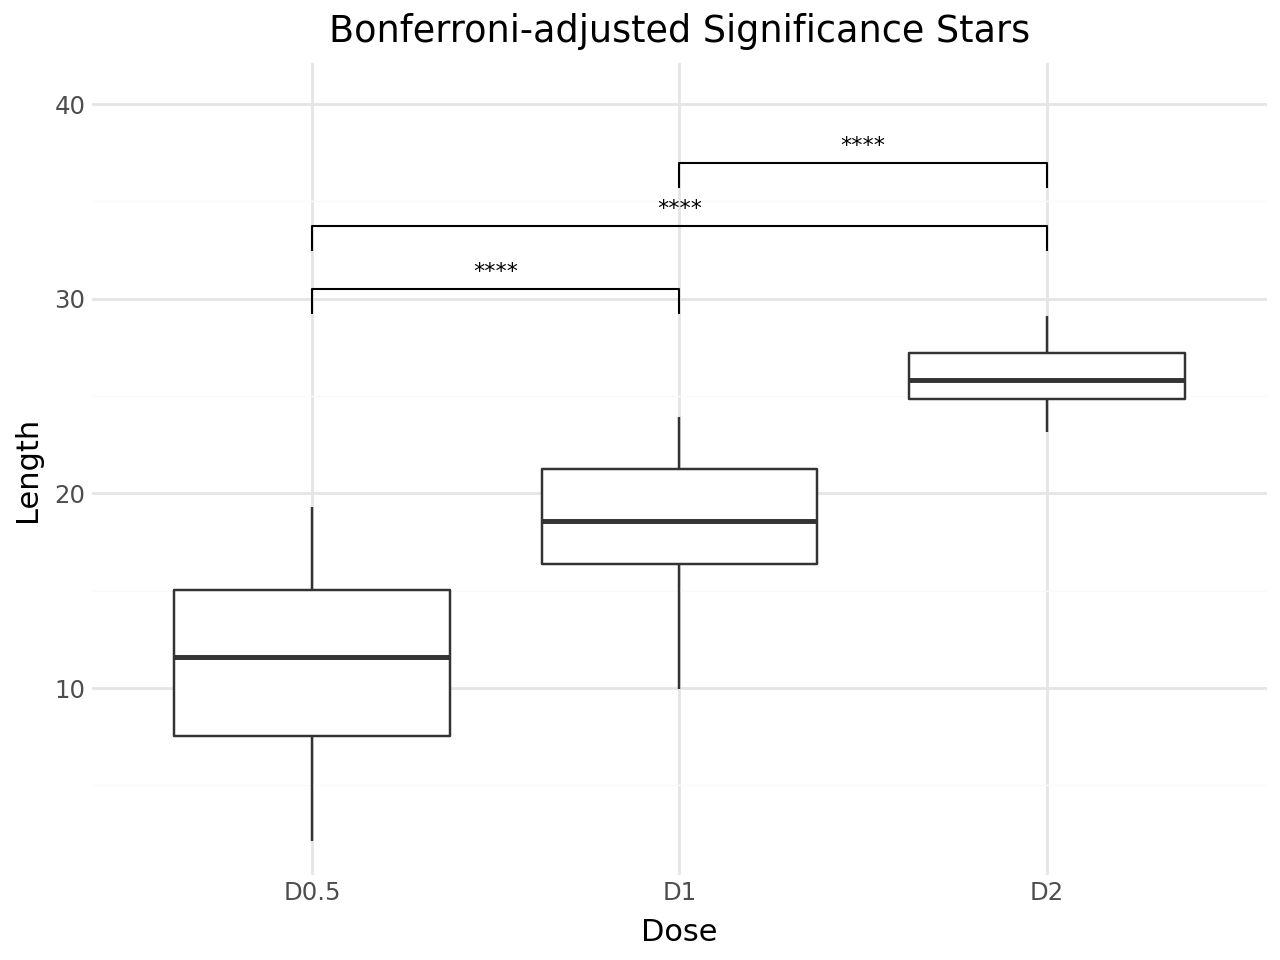

In [8]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot()
    + stat_pwc(
        label="p.adj.signif",
        p_adjust_method="bonferroni",
        method="t.test",
    )
    + scale_y_continuous(expand=(0.05, 0, 0.15, 0))
    + labs(
        title="Bonferroni-adjusted Significance Stars",
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## Hiding Non-significant Comparisons

Set `hide_ns=True` to remove non-significant comparisons (p > 0.05)
from the plot.

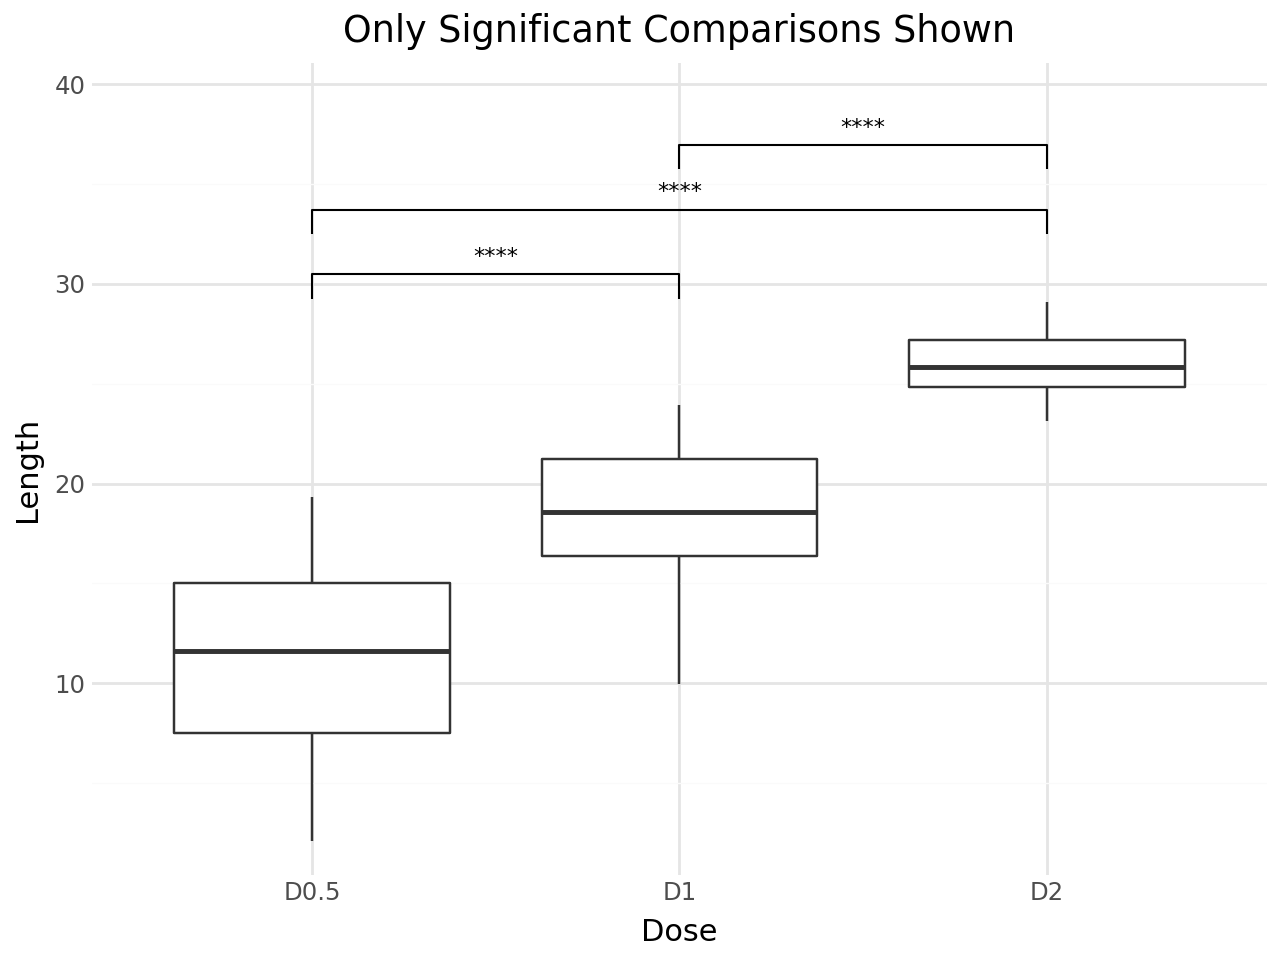

In [9]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot()
    + stat_pwc(
        label="p.signif",
        hide_ns=True,
    )
    + scale_y_continuous(expand=(0.05, 0, 0.12, 0))
    + labs(
        title="Only Significant Comparisons Shown",
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## Box plot with jittered points

`stat_pwc` can be layered with other geoms. Here the plot combines box plots,
jittered observations, and pairwise test labels.

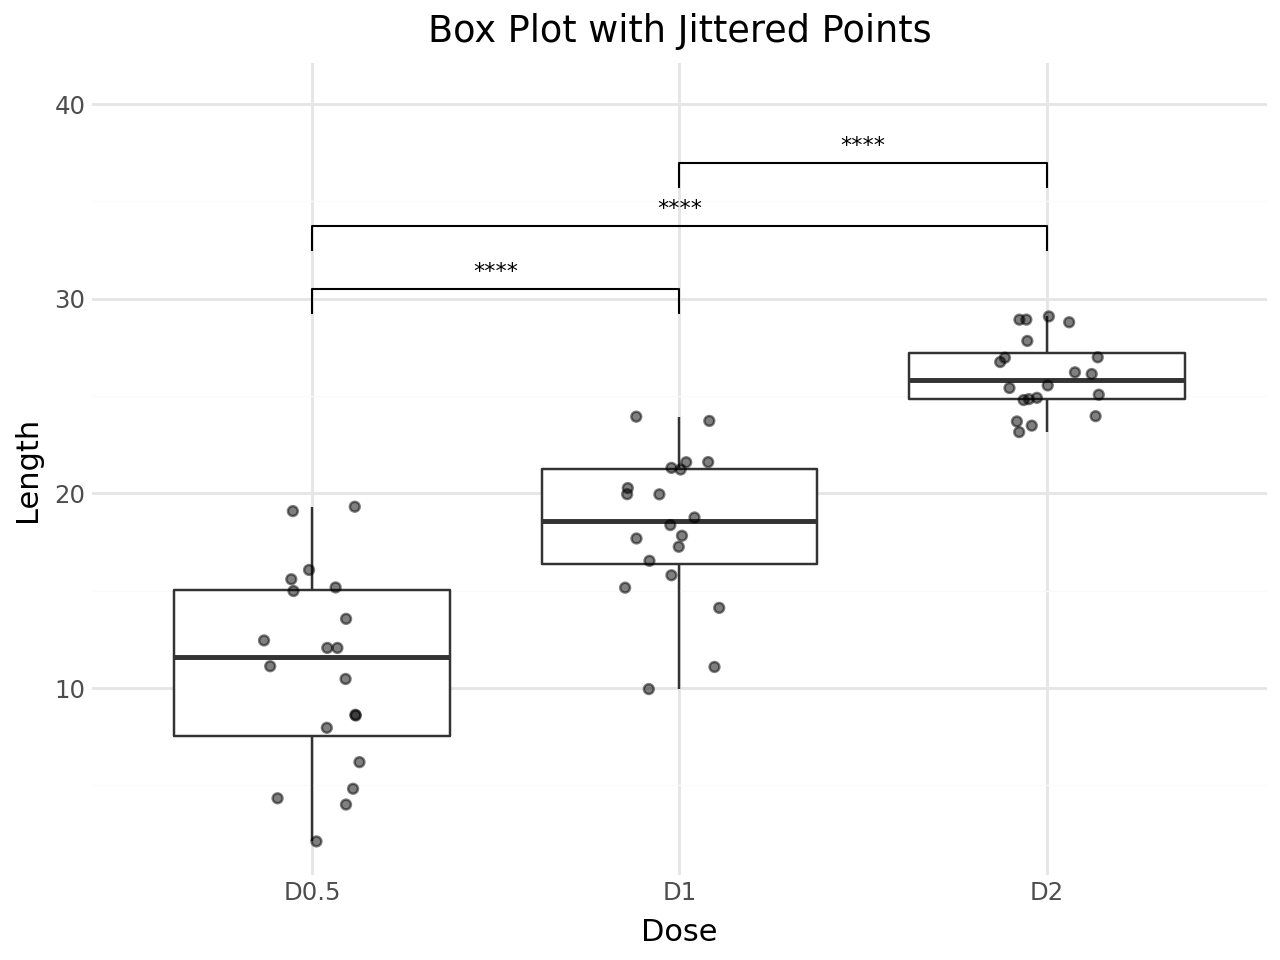

In [10]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot(outlier_shape="")
    + geom_jitter(width=0.15, alpha=0.5)
    + stat_pwc(
        method="t.test",
        label="p.signif",
    )
    + scale_y_continuous(expand=(0.05, 0, 0.15, 0))
    + labs(
        title="Box Plot with Jittered Points",
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## Customising Bracket Appearance

You can adjust the bracket layout with:

- `step_increase` – gap between stacked brackets (fraction of y-range)
- `bracket_nudge_y` – vertical offset for all brackets
- `tip_length` – length of bracket tips

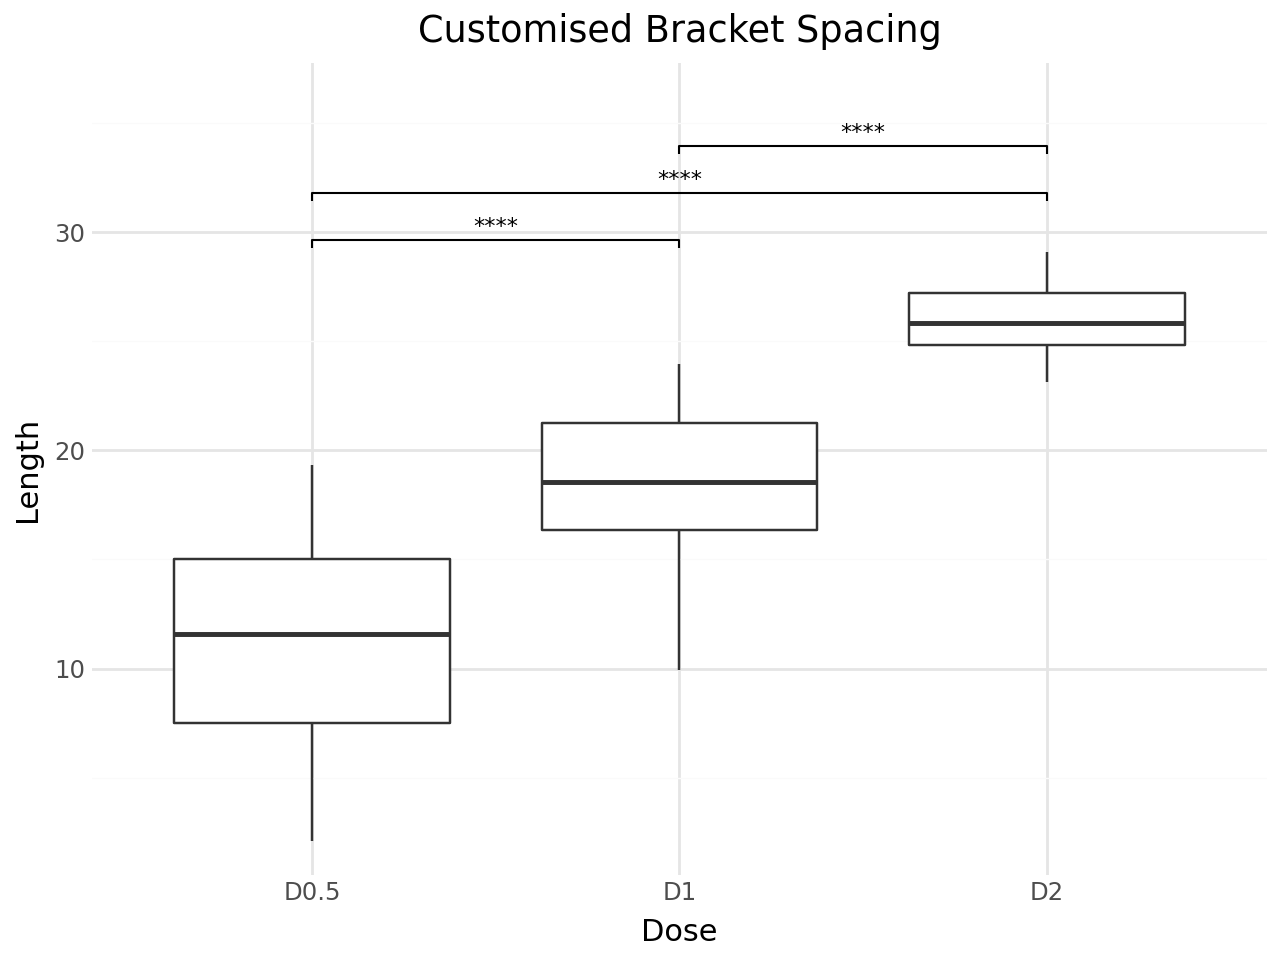

In [11]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot()
    + stat_pwc(
        label="p.signif",
        step_increase=0.08,
        bracket_nudge_y=0.02,
        tip_length=0.01,
    )
    + scale_y_continuous(expand=(0.05, 0, 0.12, 0))
    + labs(
        title="Customised Bracket Spacing",
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## Faceted Plots

`stat_pwc` works with faceted plots. Each facet panel gets its own
set of pairwise comparisons.

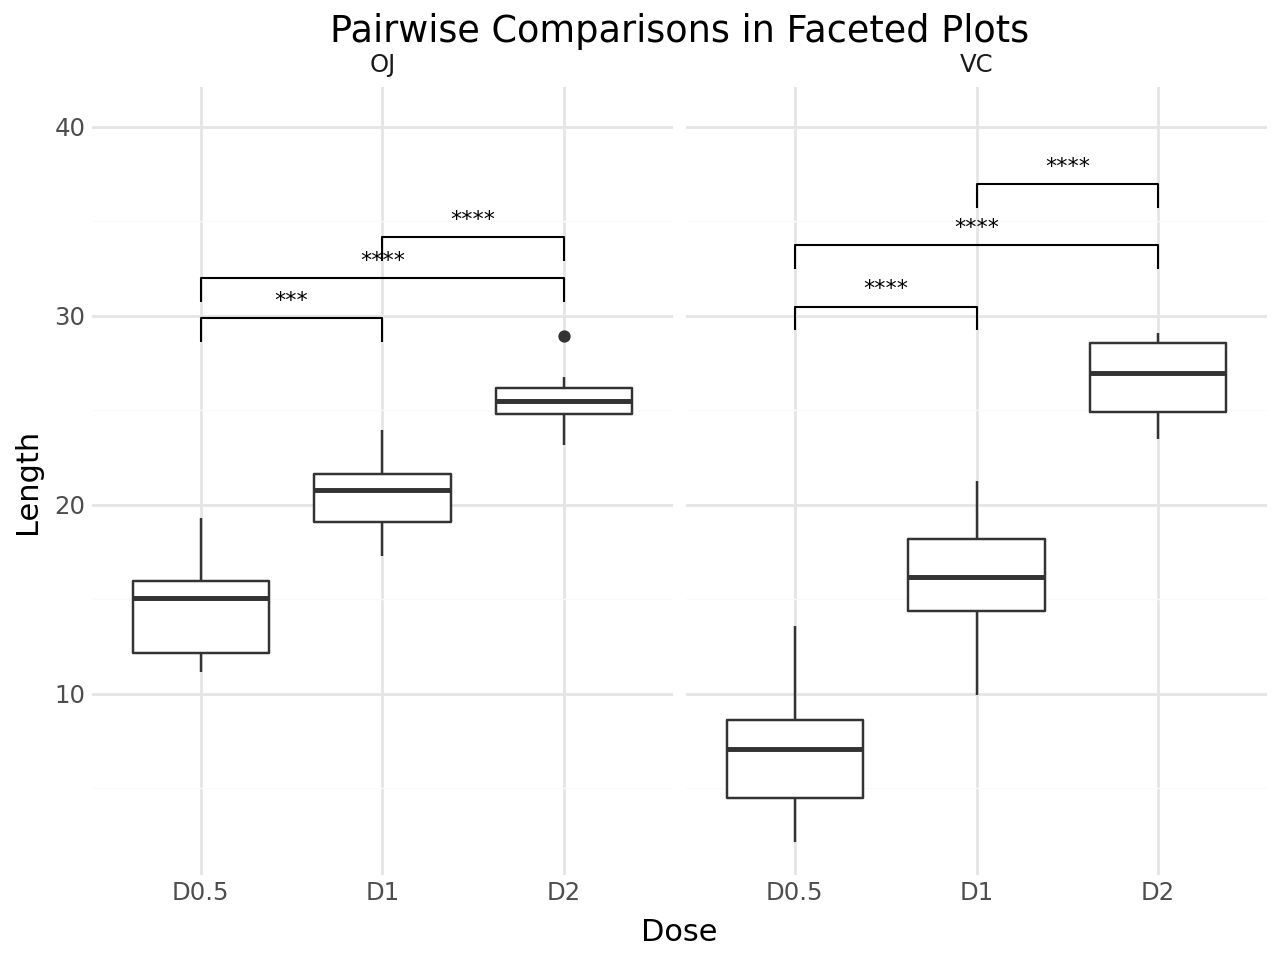

In [12]:
(
    ggplot(df, aes(x="dose", y="len"))
    + geom_boxplot()
    + stat_pwc(
        label="p.signif",
        method="t.test",
    )
    + facet_wrap("supp")
    + scale_y_continuous(expand=(0.05, 0, 0.15, 0))
    + labs(
        title="Pairwise Comparisons in Faceted Plots",
        x="Dose",
        y="Length",
    )
    + theme_minimal()
)

## Paired tests with `wid`

For paired or repeated-measures comparisons, set `paired=True` and provide
`wid`, the column that identifies the subject or matched unit. plotnine-extra
validates that each subject has one observation in each compared group and
raises an error for duplicate or incomplete pairs.

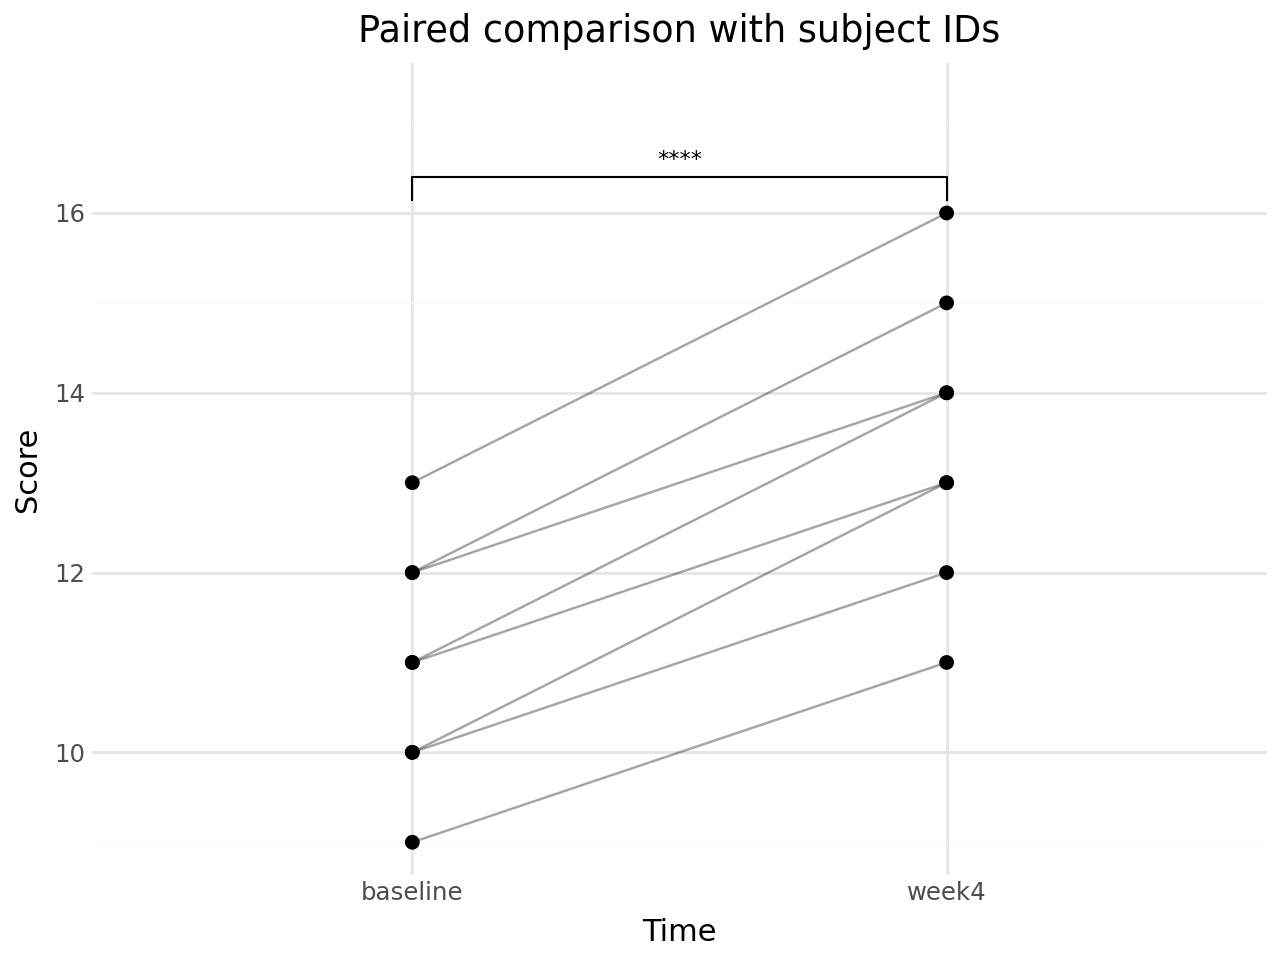

In [13]:
subjects = [f"S{i}" for i in range(1, 9)]
paired_df = pd.DataFrame({
    "subject": subjects * 2,
    "time": ["baseline"] * 8 + ["week4"] * 8,
    "score": [
        10, 12, 9, 11, 13, 10, 12, 11,
        13, 15, 11, 14, 16, 12, 14, 13,
    ],
})

(
    ggplot(paired_df, aes(x="time", y="score"))
    + geom_line(aes(group="subject"), alpha=0.35)
    + geom_point(size=2)
    + stat_pwc(
        method="t.test",
        paired=True,
        wid="subject",
        comparisons=[("baseline", "week4")],
        label="p.signif",
    )
    + scale_y_continuous(expand=(0.05, 0, 0.18, 0))
    + labs(
        title="Paired comparison with subject IDs",
        x="Time",
        y="Score",
    )
    + theme_minimal()
)

## Text-only annotations

Set `remove_bracket=True` to switch the default geom from `geom_bracket` to
`geom_text`. This is appropriate when brackets would obscure nearby data or
when the compared groups are already clear from the axis labels.

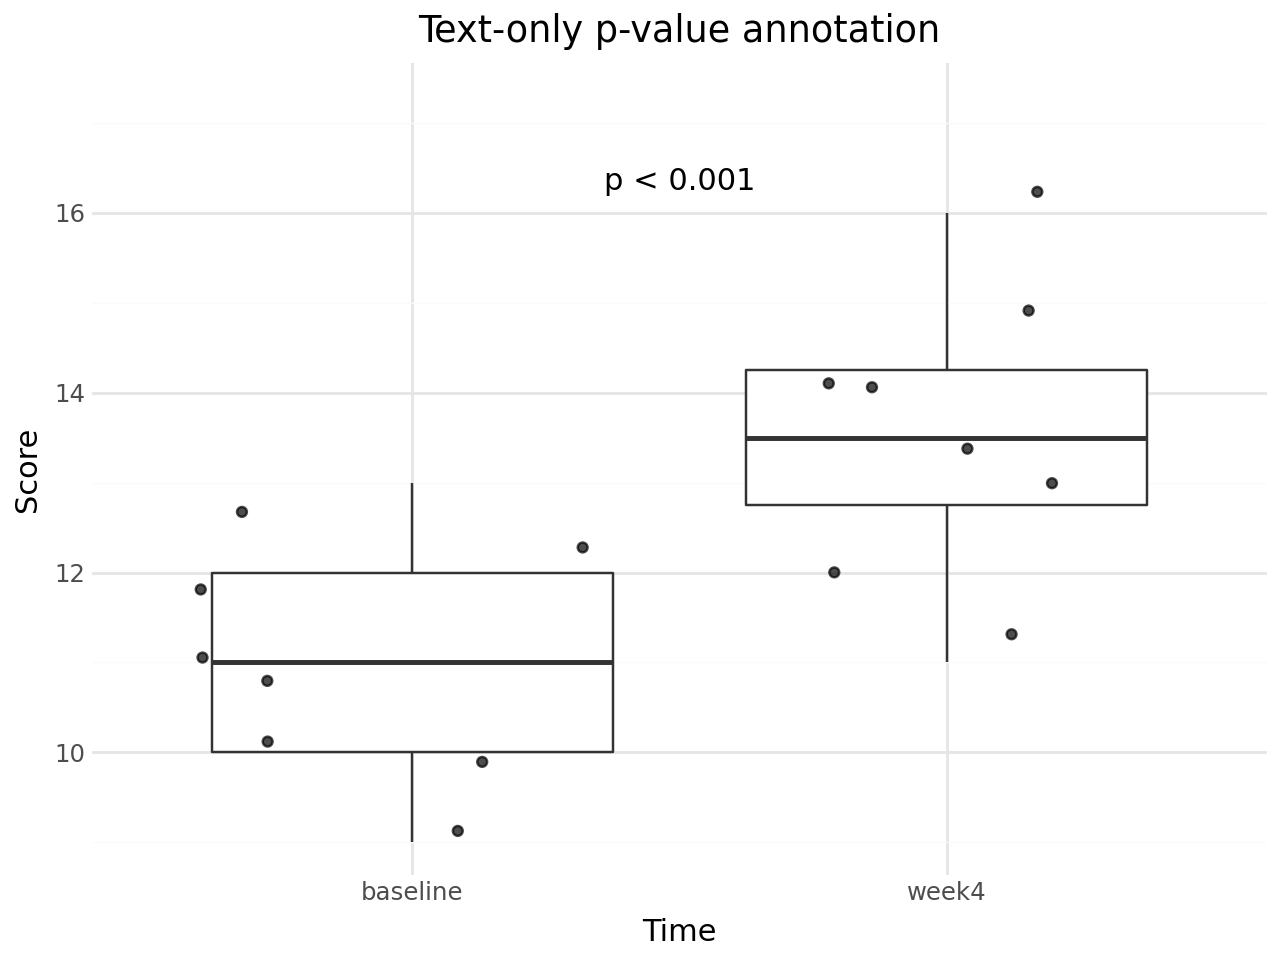

In [14]:
(
    ggplot(paired_df, aes(x="time", y="score"))
    + geom_boxplot(outlier_shape="")
    + geom_point(position="jitter", alpha=0.7)
    + stat_pwc(
        method="t.test",
        paired=True,
        wid="subject",
        comparisons=[("baseline", "week4")],
        label="p.format",
        remove_bracket=True,
    )
    + scale_y_continuous(expand=(0.05, 0, 0.18, 0))
    + labs(
        title="Text-only p-value annotation",
        x="Time",
        y="Score",
    )
    + theme_minimal()
)

## Available Label Formats

| `label` value | Description |
|---------------|-------------|
| `"p.format"` | Formatted raw p-value (default) |
| `"p.signif"` | Significance symbols (ns, \*, \*\*, \*\*\*, \*\*\*\*) |
| `"p.adj.format"` | Formatted adjusted p-value |
| `"p.adj.signif"` | Adjusted significance symbols |
| `"p.format.signif"` | Raw p-value with significance symbol |

## Available P-value Adjustment Methods

| `p_adjust_method` | Description |
|-------------------|-------------|
| `"holm"` | Holm (default, step-down) |
| `"bonferroni"` | Bonferroni |
| `"hochberg"` | Hochberg |
| `"BH"` or `"fdr"` | Benjamini-Hochberg (FDR) |
| `"BY"` | Benjamini-Yekutieli |
| `"hommel"` | Hommel |
| `"none"` | No adjustment |

## Covered options

This vignette covered:

- all pairwise tests or comparisons against a reference group
- Wilcoxon rank-sum tests and t-tests
- paired tests with `paired=True` and a required `wid` subject identifier
- p-value adjustment for multiple comparisons
- p-value labels, significance-star labels, and adjusted-p labels
- bracket spacing, tips, nudging, and text-only labels with
  `remove_bracket=True`
- faceted plots, with comparisons computed per panel

For more details, see the
[API reference](../api/stats.rst#stat-pwc).